In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.cm as cm
cmap = cm.get_cmap('magma')
size=12
params = {'legend.fontsize': 'large',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
          'axes.titlepad': 5,
          'lines.linewidth': 2,
          'figure.dpi': 100}
plt.rcParams.update(params)

data_dir = 'raw_data_kymos/'

from SVD_analysis.src.data_settings import sample_colors, sample_dt, sample_temperatures, sample_somite_stage

from SVD_analysis.src.data_settings import load_kymo
from SVD_analysis.src.SVD_functions import posterior_kymo


/var/folders/yn/r99j3qy962lg5cwmzc1dpqg40000gn/T/ipykernel_14284/3069576665.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('magma')


In [2]:
sample_names = {
    'TE_22C_14ss': {'20210301': [1, 2, 4, 5, 6, 7]},
    'TE_22C_15ss': {'20200817': [1, 4, 6, 7, 8, 9]},
    'TE_27C_14ss': {'20200815': [1, 2, 3],
                    '20210310': [2, 3, 4, 5, 6, 7]},
    #     'TE_27C_14ss_wt': {'20210610': [2, 4, 5, 6, 7, 9, 10]},
    'TE_27C_17ss': {'20200815': [6, 8, 9, 10]},
        'TE_32C_15ss': {'20210224': [1, 2, 3, 4, 6, 9, 10],
                        '20210325': [1, 3, 4, 5, 6, 7, 8]},
    'TE_32C_14ss_5dt': {'20220428': [1, 2, 3, 4, 5],
                        '20220429': [1, 2, 3, 4, 5],
                        '20220430': [1, 2, 3, 4, 5]}, }

In [3]:
tuples = []
for exp in sample_names:
    for date in sample_names[exp]:
        for loc in sample_names[exp][date]:
            tuples.append((exp, date, loc))

index = pd.MultiIndex.from_tuples(tuples, names=["Experiment", "Date", "P"])

df = pd.DataFrame(index=index, columns=['Temp', 'ss', 'dt', 'color'])
df = df.sort_index()
for exp in df.index.levels[0]:
    df.loc[exp, 'Temp'] = sample_temperatures[exp]
    df.loc[exp, 'dt'] = sample_dt[exp]
    df.loc[exp, 'ss'] = sample_somite_stage[exp]
    df.loc[exp, 'color'] = sample_colors[exp]

df.head(3)

Temp  ss    dt    color
Experiment  Date     P                         
TE_22C_14ss 20210301 1  22.0  14  10.0  #31688e
                     2  22.0  14  10.0  #31688e
                     4  22.0  14  10.0  #31688e

In [4]:
def velocities_from_kymo(masked_phi, T0, dx=1.38, dt=1.):
    psm_edges = np.ma.notmasked_edges(masked_phi, axis=0)
    tt = np.arange(masked_phi.shape[1]) * dt/T0

    fit_f, pcov_f = np.polyfit(tt, psm_edges[0][0]*dx, 1, cov=True)
    fit_tb, pcov_tb = np.polyfit(tt, psm_edges[1][0]*dx, 1, cov=True)
    perr_f = np.sqrt(np.diag(pcov_f))
    perr_tb = np.sqrt(np.diag(pcov_tb))

    return fit_f, fit_tb

In [5]:
def rescaled_time_kymo(data_dir, exp, date, sample, T0, n_cycles, n_hours, length, dt, ax_osc = None, dx=1.38, flip_x = False):
    mask_kymo = ~ load_kymo('mask', data_dir, exp, date, sample, naming).astype('bool')
    coords = np.argwhere(mask_kymo)
    x_min, y_min = coords.min(axis=0)
    x_max, y_max = coords.max(axis=0)
    # if x_max - x_min < length:
    #     padding = length - (x_max - x_min)


    mask_kymo = mask_kymo[x_min:x_min+length, y_min:y_max + 1]
    intensity_kymo = load_kymo('intensity', data_dir, exp, date, sample, naming)[x_min:x_min+length, y_min:]
    growth_duration = min(int(n_hours*60//dt), y_max)
    masked_mask = np.ma.MaskedArray(np.ones(mask_kymo.shape, dtype='int'), mask=~mask_kymo)[:, :growth_duration]

    detrended_kymo = load_kymo('detrended', data_dir, exp, date, sample, naming)[x_min:x_min+length, y_min:y_max + 1]
    detrended_kymo = np.ma.MaskedArray(detrended_kymo, mask=~mask_kymo)
    detrended_kymo = posterior_kymo(detrended_kymo)


    fit_f, fit_tb = velocities_from_kymo(masked_mask, T0, dx, dt)
    v_cm = fit_tb[0]*0.5

    xx = np.arange(length)*dx

    tt = np.arange(intensity_kymo.shape[1])*dt
    tt_hours = tt/60
    tt_cycle = tt/T0


    max_n_cycles = tt[-1]//T0
    if max_n_cycles < n_cycles:
        n_cycles = max_n_cycles
        print('not long enough kymo')


    row = -22
    detrended_duration = detrended_kymo.shape[1]

    if ax_osc is not None:
        osc = detrended_kymo[row, :]/np.mean(np.abs(detrended_kymo[row, :]))/2
        ax_osc[0].plot(tt_hours[:detrended_duration], osc, c = sample_colors[exp], alpha=0.7)
        ax_osc[1].plot(tt_cycle[:detrended_duration], osc, c = sample_colors[exp], alpha=0.7)


    kymo = intensity_kymo[:, tt_hours<=n_hours]
    kymo[np.isnan(kymo)] = np.min(intensity_kymo)
    tt_plot = tt_hours[tt_hours<=n_hours]

    tt_mesh, xx_mesh = np.meshgrid(tt_plot, xx, indexing='xy')


    plt.figure(figsize=(2.2,4))
    plt.pcolormesh(tt_mesh, xx_mesh+v_cm*tt_mesh*60/T0, kymo, shading='auto', cmap='magma', vmin=5000)
    plt.plot(tt_hours, fit_f[0]*tt_cycle + 0.5*fit_tb[0]*tt_cycle+ fit_f[1], lw=2, c='w')
    plt.plot(tt_hours, 1.5*fit_tb[0]*tt_cycle + fit_tb[1], lw=2, c='w')
    plt.plot(tt_hours, 1.5*fit_tb[0]*tt_cycle + fit_tb[1] + dx*row, '--', lw=2, c='w')
    plt.xticks(np.arange(0, n_hours+1, 2))
    plt.xlim((0, n_hours))
    plt.ylim((0, 1.2*length*1.38))
    plt.gca().invert_yaxis()
    plt.ylabel('Space (um)')
    plt.xlabel('Time (hours)')
    ax_hours = plt.gca()
    # plt.show()

    # ____________________________________________

    kymo = intensity_kymo[:, tt_cycle<=n_cycles]
    kymo[np.isnan(kymo)] = np.min(intensity_kymo)
    tt_plot = tt_cycle[tt_cycle<=n_cycles]

    tt_mesh, xx_mesh = np.meshgrid(tt_plot, xx, indexing='xy')


    plt.figure(figsize=(2.2, 4))
    plt.pcolormesh(tt_mesh, xx_mesh+v_cm*tt_mesh, kymo, shading='auto', cmap='magma', vmin=5000)
    plt.plot(tt_cycle, fit_f[0]*tt_cycle + + 0.5*fit_tb[0]*tt_cycle + fit_f[1], lw=2, c='w')
    plt.plot(tt_cycle, 1.5*fit_tb[0]*tt_cycle + fit_tb[1], lw=2, c='w')
    plt.plot(tt_cycle, 1.5*fit_tb[0]*tt_cycle + fit_tb[1] +dx*row, '--', lw=2, c='w')

    plt.xticks(np.arange(0, n_cycles+1, 1))
    plt.xlim((0, n_cycles))
    plt.ylim((0, 1.2*length*1.38))
    plt.gca().invert_yaxis()
    plt.ylabel('Space (um)')
    plt.xlabel('Time (cycles)')
    # plt.show()
    ax_cycle = plt.gca()

    return ax_hours, ax_cycle, fit_f, fit_tb, tt_cycle, tt

TE_22C_14ss 20210301 4
TE_27C_14ss 20210310 6
TE_32C_14ss_5dt 20220429 3


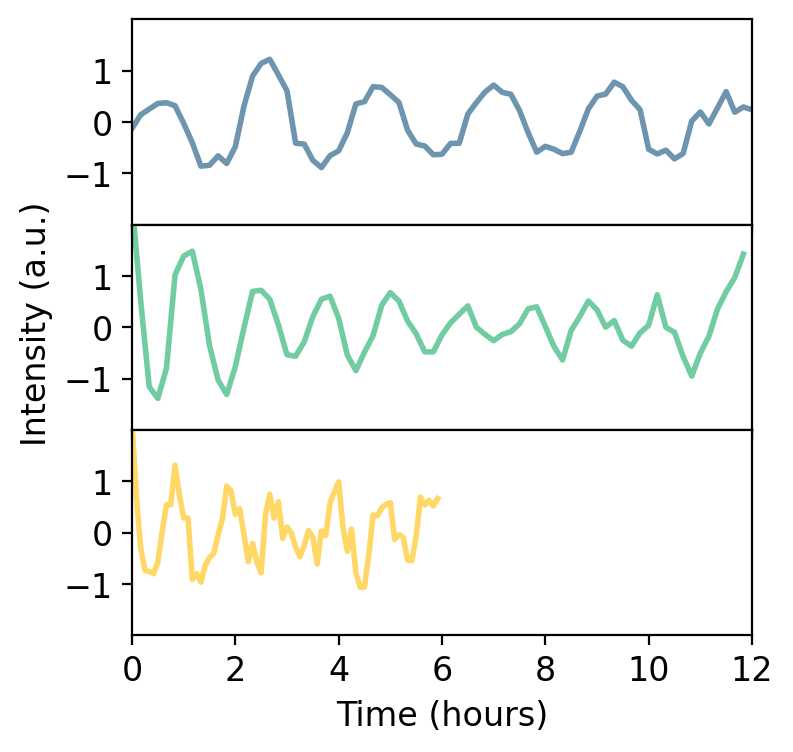

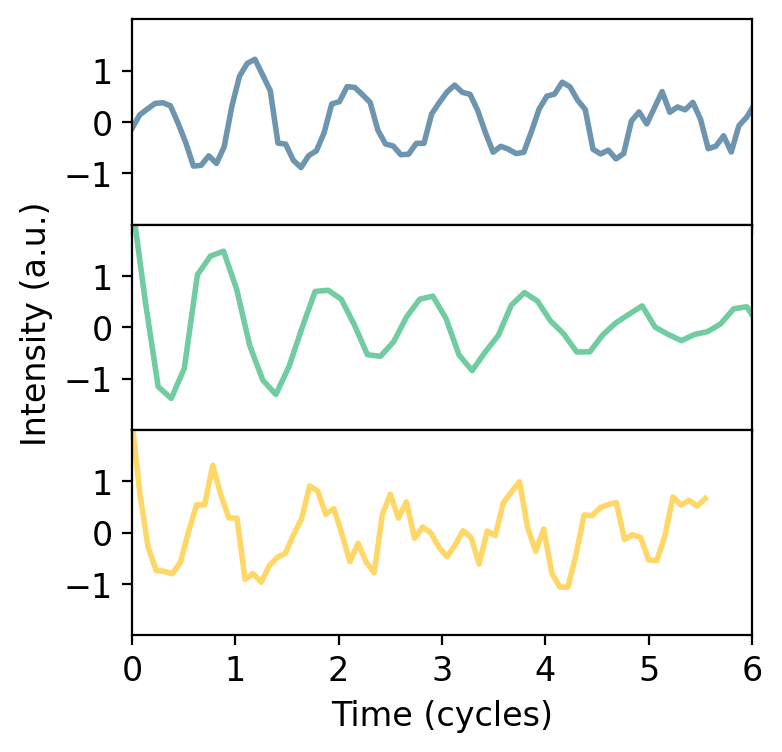

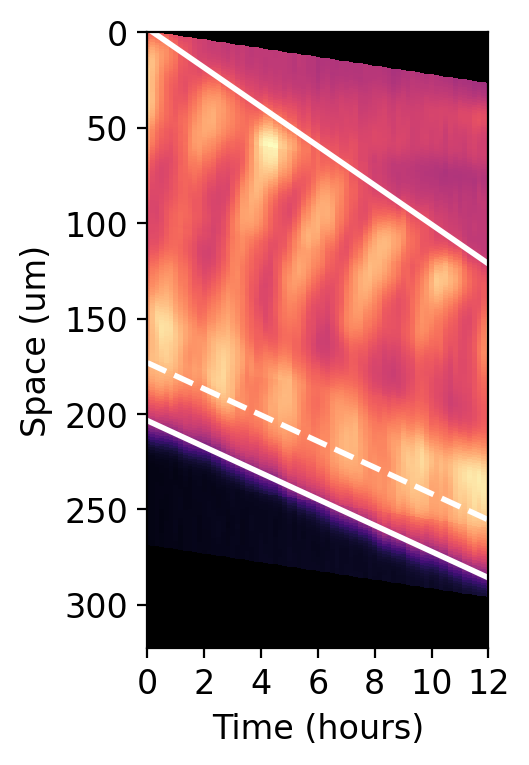

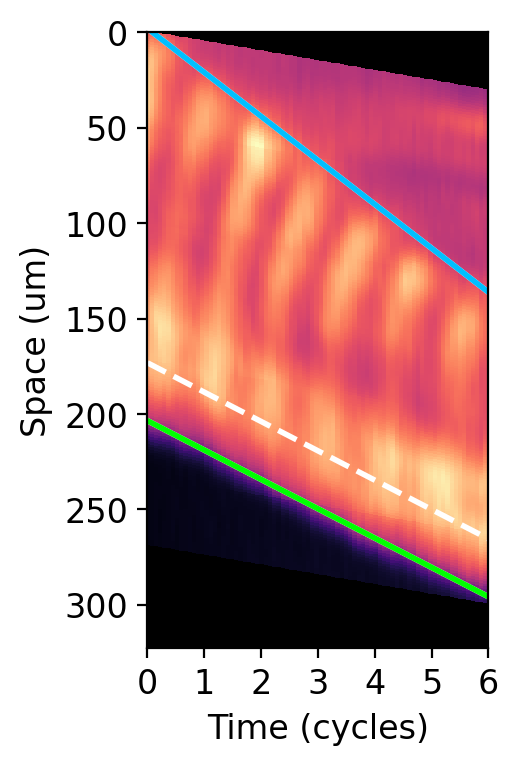

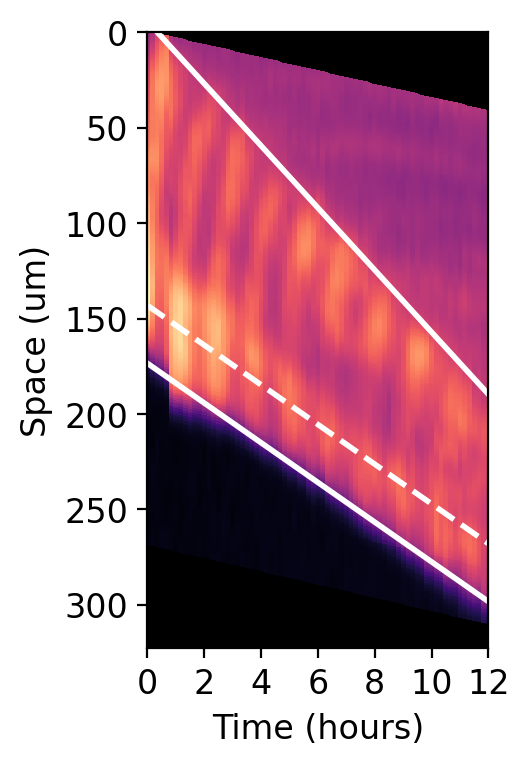

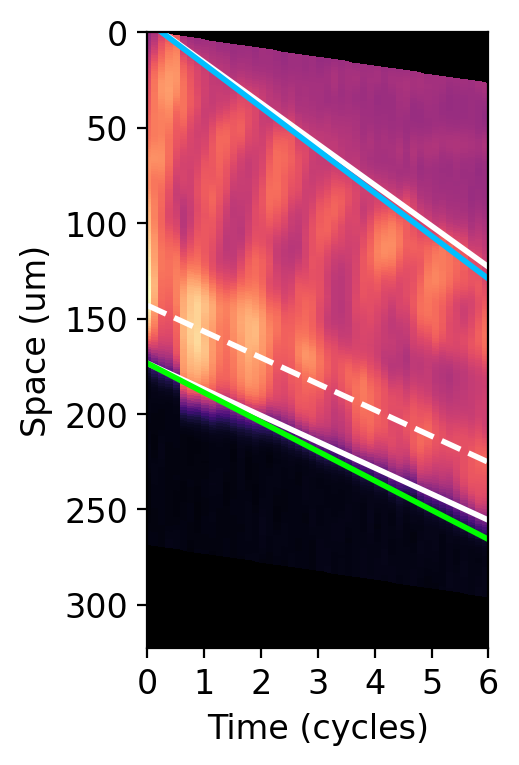

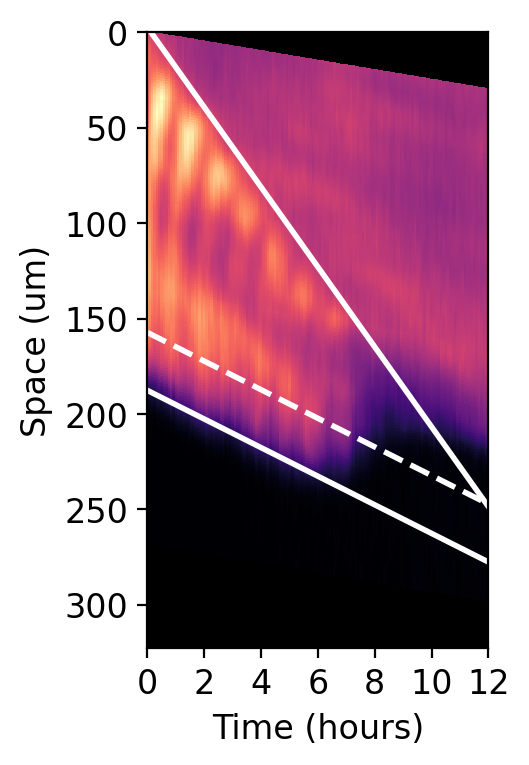

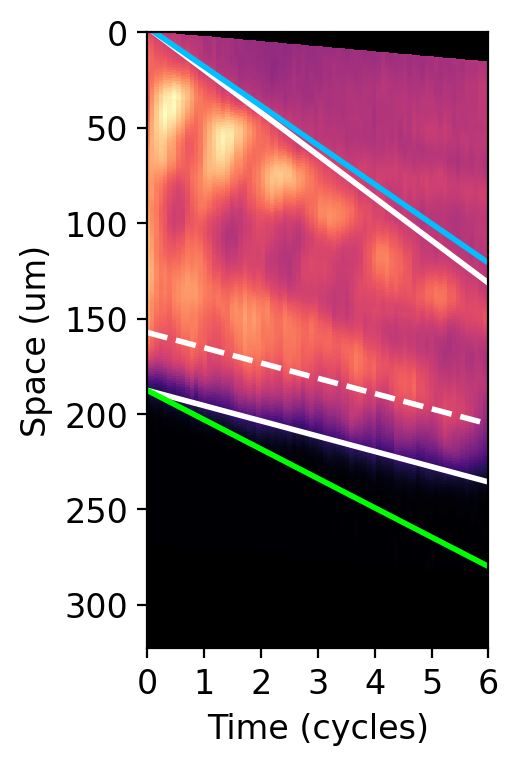

In [6]:
naming= 'default'

fig, ax_osc_h = plt.subplots(3, 1, sharex=True, figsize=(4, 4))
fig.subplots_adjust(hspace=0.)
plt.xlim((0, 12))
plt.xlabel('Time (hours)')
fig.supylabel('Intensity (a.u.)', x = -0.015)
for axi in ax_osc_h:
    axi.set_ylim((-2, 2))
    axi.set_yticks((-1, 0, 1))
#
#
fig, ax_osc_c = plt.subplots(3, 1, sharex=True, figsize=(4, 4))
fig.subplots_adjust(hspace=0.0)
plt.xlim((0,6))
plt.xlabel('Time (cycles)')
fig.supylabel('Intensity (a.u.)', x = -0.015)

for axi in ax_osc_c:
    axi.set_ylim((-2, 2))
    axi.set_yticks((-1, 0, 1))



##  22 C
id = 2; T0 = 134.5

(exp, date, sample) = df.index[id]
print(exp, date, sample)
dt = sample_dt[exp]
ax_hours, ax_cycle, fit_f, fit_tb, tt_cycle, tt = rescaled_time_kymo(data_dir, exp, date, sample, T0, 6, 12, 195, dt, (ax_osc_h[0], ax_osc_c[0]))
fit_f_22 = fit_f
fit_tb_22 = fit_tb
ax_cycle.plot(tt_cycle, fit_f[0]*tt_cycle + 0.5*fit_tb[0]*tt_cycle + fit_f[1], lw=2, c='deepskyblue')
ax_cycle.plot(tt_cycle, 1.5*fit_tb[0]*tt_cycle + fit_tb[1], lw=2, c='lime')
ax_hours.set_facecolor('k')
ax_cycle.set_facecolor('k')


## 27 C
id = 19; T0 = 79

(exp, date, sample) = df.index[id]
print(exp, date, sample)
dt = sample_dt[exp]
ax_hours, ax_cycle, fit_f, fit_tb, tt_cycle, tt = rescaled_time_kymo(data_dir, exp, date, sample, T0, 6, 12, 195, dt, (ax_osc_h[1], ax_osc_c[1]))
ax_cycle.plot(tt_cycle, fit_f_22[0]*tt_cycle + 0.5*fit_tb[0]*tt_cycle + fit_f[1], lw=2, c='deepskyblue')
ax_cycle.plot(tt_cycle, 1.5*fit_tb_22[0]*tt_cycle + fit_tb[1], lw=2, c='lime')
ax_hours.set_facecolor('k')
ax_cycle.set_facecolor('k')

## 32 C
id = 32; T0 = 64

(exp, date, sample) = df.index[int(id)]
print(exp, date, sample)
dt = sample_dt[exp]
ax_hours, ax_cycle, fit_f, fit_tb, tt_cycle, tt = rescaled_time_kymo(data_dir, exp, date, sample, T0, 6, 12, 195, dt, (ax_osc_h[2], ax_osc_c[2]))
ax_cycle.plot(tt_cycle, fit_f_22[0]*tt_cycle + 0.5*fit_tb[0]*tt_cycle + fit_f[1], lw=2, c='deepskyblue')
ax_cycle.plot(tt_cycle, 1.5*fit_tb_22[0]*tt_cycle + fit_tb[1], lw=2, c='lime')
ax_hours.set_facecolor('k')
ax_cycle.set_facecolor('k')
plt.show()

